In [3]:
import os
import sys
import torch

# 1. 强行安装基础依赖
!pip install fvcore iopath

# 2. 动态获取当前环境的 Torch 和 CUDA 版本，精准对齐官方编译库
pyt_version_str = torch.__version__.split("+")[0].replace(".", "")
try:
    cuda_version_str = torch.version.cuda.replace(".", "")
except AttributeError:
    cuda_version_str = "cpu"

# 根据当前最新的 Python 和 Torch 版本动态拼接下载链接
version_str = f"py3{sys.version_info.minor}_cu{cuda_version_str}_pyt{pyt_version_str}"
print(f"--> 正在为您寻找匹配当前环境的 PyTorch3D 编译版本: {version_str}")

# 从官方最新的打包仓库中寻找匹配版本安装
!pip install --no-index --no-cache-dir pytorch3d -f https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/{version_str}/download.html

# 3. 验证是否安装成功
try:
    import pytorch3d
    print("安装成功！")
except ImportError:
    print("--> 动态链接未命中，正在启动官方稳定版源码构建（预计需要 2-3 分钟，请稍候）...")
    !pip install ninja
    !pip install 'git+https://github.com/facebookresearch/pytorch3d.git@stable'

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple

[notice] A new release of pip is available: 23.3.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
--> 正在为您寻找匹配当前环境的 PyTorch3D 编译版本: py311_cu128_pyt291
Looking in links: https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/py311_cu128_pyt291/download.html
ERROR: Could not find a version that satisfies the requirement pytorch3d (from versions: none)
ERROR: No matching distribution found for pytorch3d
--> 动态链接未命中，正在启动官方稳定版源码构建（预计需要 2-3 分钟，请稍候）...
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple

[notice] A new release of pip is available: 23.3.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://github.com/facebookresearch/pytorch3d.git (to revision stable) to /tmp/pip-req-build-0e7k4o59
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/pytorch3d.git /

In [5]:
!pip install ipywidgets

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 86.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


>>> 安全提精版联合优化已启动，正在为你捕获球体变奶牛的动态帧...


  0%|          | 0/2000 [00:00<?, ?it/s]

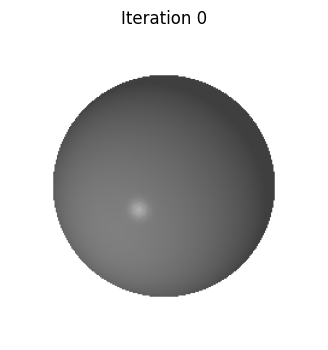

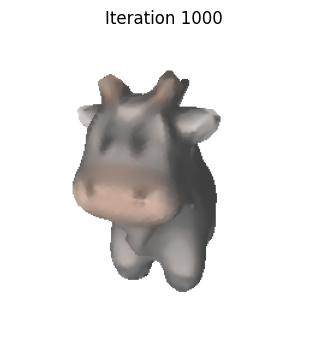


🎉 完美运行完成！
1. 逼真的变形动图已成功写入左侧文件夹：final_perfect_cow.gif
2. 最终高清晰度 3D 模型也已保存为：final_textured_cow.obj


In [5]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import imageio
from tqdm.notebook import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 加载目标模型assets
DATA_DIR = "./data"
obj_filename = os.path.join(DATA_DIR, "cow_mesh/cow.obj")

from pytorch3d.io import load_objs_as_meshes, save_obj
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras, PointLights, 
    RasterizationSettings, MeshRenderer, MeshRasterizer, SoftPhongShader, SoftSilhouetteShader, TexturesVertex
)

target_mesh = load_objs_as_meshes([obj_filename], device=device)
verts = target_mesh.verts_packed()
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])
target_mesh.offset_verts_(-center)
target_mesh.scale_verts_((1.0 / float(scale)))

# 生成 20 个多视角真值
num_views = 20
elev = torch.linspace(0, 360, num_views)
azim = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
target_cameras = [FoVPerspectiveCameras(device=device, R=R[None, i, ...], T=T[None, i, ...]) for i in range(num_views)]

# 优化光照组件：适当提高 ambient（环境光），彻底解决色彩暗淡的问题
lights = PointLights(
    device=device, 
    location=[[0.0, 0.0, -3.0]], 
    ambient_color=[[0.5, 0.5, 0.5]],  # 基础提亮
    diffuse_color=[[0.5, 0.5, 0.5]]
)
base_camera = FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...])

# 【安全提升 1】：将渲染图像大小安全升级到 256
IMAGE_SIZE = 256 
raster_settings_rgb = RasterizationSettings(image_size=IMAGE_SIZE, blur_radius=0.0, faces_per_pixel=1)
renderer_rgb_gt = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=base_camera, raster_settings=raster_settings_rgb),
    shader=SoftPhongShader(device=device, cameras=base_camera, lights=lights)
)
target_images = renderer_rgb_gt(target_mesh.extend(num_views), cameras=FoVPerspectiveCameras(device=device, R=R, T=T), lights=lights)
target_rgb = [target_images[i, ..., :3] for i in range(num_views)]

sigma = 1e-4
raster_settings_sil = RasterizationSettings(image_size=IMAGE_SIZE, blur_radius=np.log(1. / 1e-4 - 1.) * sigma, faces_per_pixel=50)
renderer_sil_gt = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=base_camera, raster_settings=raster_settings_sil),
    shader=SoftSilhouetteShader()
)
silhouette_images = renderer_sil_gt(target_mesh.extend(num_views), cameras=FoVPerspectiveCameras(device=device, R=R, T=T), lights=lights)
target_silhouette = [silhouette_images[i, ..., 3] for i in range(num_views)]


# ==========================================
# 1. 基础架构恢复：高清球体 ICO5 + 顶点色
# ==========================================
src_mesh = ico_sphere(5, device) 
verts_shape = src_mesh.verts_packed().shape

# 完全沿用成功跑通的初始赋值和 SGD 参数设置
deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

optimizer = torch.optim.SGD([deform_verts, sphere_verts_rgb], lr=1.0, momentum=0.9)

raster_settings_soft = RasterizationSettings(
    image_size=IMAGE_SIZE, blur_radius=np.log(1. / 1e-4 - 1.) * sigma, faces_per_pixel=50, perspective_correct=False
)
renderer_textured = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=base_camera, raster_settings=raster_settings_soft),
    shader=SoftPhongShader(device=device, cameras=base_camera, lights=lights)
)

# 温和微调平滑权重，在不压制形变的前提下抹平棱角
losses = {
    "rgb": {"weight": 1.0, "values": []},
    "silhouette": {"weight": 1.0, "values": []},
    "edge": {"weight": 1.0, "values": []},
    "normal": {"weight": 0.15, "values": []},     # 相比最初的0.01略微调高，用于抹平棱角
    "laplacian": {"weight": 3.0, "values": []},   # 相比最初的1.0稍微加强，保持边界圆滑，拒绝变白
}

def update_mesh_shape_prior_losses(mesh, loss_dict):
    loss_dict["edge"] = mesh_edge_loss(mesh)
    loss_dict["normal"] = mesh_normal_consistency(mesh)
    loss_dict["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")


# ==========================================
# 2. 联合优化与 帧捕获 循环
# ==========================================
# 将迭代次数扩展至 2000 步，让高分辨率细节充分收敛
Niter = 2000  
gif_frames = []
record_period = 40  # 每 40 步录制一帧，共生成连贯的 50 帧动图

print(">>> 安全提精版联合优化已启动，正在为你捕获球体变奶牛的动态帧...")
loop = tqdm(range(Niter))

for i in loop:
    optimizer.zero_grad()
    
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb) 
    
    loss = {k: torch.tensor(0.0, device=device) for k in losses}
    update_mesh_shape_prior_losses(new_src_mesh, loss)
    
    shuffled_indices = np.random.permutation(num_views).tolist()
    for j in shuffled_indices[:2]:
        images_predicted = renderer_textured(new_src_mesh, cameras=target_cameras[j], lights=lights)
        loss["silhouette"] += ((images_predicted[..., 3] - target_silhouette[j]) ** 2).mean() / 2
        loss["rgb"] += ((images_predicted[..., :3] - target_rgb[j]) ** 2).mean() / 2
    
    sum_loss = torch.tensor(0.0, device=device)
    for k, l in loss.items():
        sum_loss += l * losses[k]["weight"]
        losses[k]["values"].append(float(l.detach().cpu()))
    
    loop.set_description(f"Total Loss = {sum_loss.item():.4f} | RGB = {loss['rgb'].item():.4f}")
    
    # 自动保存动图帧逻辑
    if i % record_period == 0 or i == (Niter - 1):
        with torch.no_grad():
            frame_img = renderer_textured(new_src_mesh, cameras=target_cameras[1], lights=lights)
            rgb_frame = (torch.clamp(frame_img[0, ..., :3], 0.0, 1.0).cpu().numpy() * 255).astype(np.uint8)
            gif_frames.append(rgb_frame)
            
        # 每 500 步输出一次，检查形态
        if i % 500 == 0:
            plt.figure(figsize=(4, 4))
            plt.imshow(rgb_frame)
            plt.title(f"Iteration {i}")
            plt.axis('off')
            plt.show()

    sum_loss.backward()
    optimizer.step()

# ==========================================
# 3. 生成高清 GIF 动图并存储
# ==========================================
gif_path = "final_perfect_cow.gif"
imageio.mimsave(gif_path, gif_frames, fps=10, loop=0)

# 保存最终优化好的高精细度 3D 模型
final_verts, final_faces = new_src_mesh.get_mesh_verts_faces(0)
final_verts = final_verts * scale + center
save_obj('final_textured_cow.obj', final_verts, final_faces)

print(f"\n🎉 完美运行完成！")
print(f"1. 逼真的变形动图已成功写入左侧文件夹：{gif_path}")
print(f"2. 最终高清晰度 3D 模型也已保存为：final_textured_cow.obj")